# Cinematic black-hole flythrough (GPU)

A camera orbits a spinning (Kerr) black hole while a GPU traces one light ray per
pixel, backward through the curved spacetime, for every frame. What you get is the
lensed accretion disk with its Doppler + gravitational shading, the photon ring,
the shadow, and a background starfield bent into arcs by the hole's gravity.

This is the same physics as the C++ engine in `simulation/`, re-expressed as
PyTorch tensor operations so a T4 can render thousands of rays at once. Turn on
the GPU accelerator (Settings -> Accelerator -> GPU T4) before running.


In [1]:
import subprocess, sys
# imageio-ffmpeg gives us an mp4 encoder; torch and imageio ship on Kaggle.
try:
    import imageio_ffmpeg  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "imageio-ffmpeg"])

import torch
torch.set_default_dtype(torch.float32)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "CPU (enable the GPU for a real render)")


device: cuda | Tesla T4


## The engine

Tensor port of the Kerr geodesic integrator and the backward ray tracer. Written to disk, then imported.

In [2]:
%%writefile gpu_render.py
"""Vectorized Kerr ray tracer in PyTorch, for GPU rendering of flythrough frames.

This is a tensor port of the C++ engine: the Kerr inverse-metric terms (generated
by matlab/derive_kerr.m), the Hamiltonian right-hand side, and a backward ray
tracer, all rewritten so that every pixel of a frame is one row of a big state
tensor and a single GPU steps them together. The physics matches simulation/:
the same null geodesics, the same disk with its g^4 Doppler + gravitational
shading, plus a gravitationally lensed starfield behind the hole.
"""

import math
import warnings

import torch

# State columns, matching the C++ KerrIndex enum.
KT, KR, KTH, KPHI, KPT, KPR, KPTH, KPPH = range(8)


def kerr_terms(r, th, a, M):
    """Inverse-metric components and their r, theta derivatives, elementwise.

    A transcription of include/kerr_generated.hpp, with torch ops in place of
    std::sin/cos/pow so they run on whole tensors at once. The expressions are the
    generated ones, regrouped so shared pieces (sin/cos, 1/Sigma, 1/Delta, powers
    of r) are computed once: in eager mode every distinct op is a separate GPU
    kernel launch, so this alone roughly halves the kernels per RHS evaluation.
    Returns a dict of the 15 fields the RHS needs.
    """
    s = torch.sin(th)
    c = torch.cos(th)
    s2 = s * s
    c2 = c * c
    cs = c * s
    c2th = c2 - s2                           # cos(2 th)
    # On the spin axis (theta = 0 or pi) Boyer-Lindquist coordinates are singular:
    # the terms below carry 1/sin^2 and 1/sin^3. We keep this barrier HONEST (only a
    # tiny floor to avoid a literal divide-by-zero), because it is exactly the force
    # that turns a near-axis ray around; flooring it harder stops the turnaround and
    # lets the ray punch through the pole. The turnaround is instead resolved by
    # shrinking the step near the axis (see render_frame), and any ray that still
    # crosses the axis is reflected there.
    sin_safe = torch.clamp(s.abs(), min=1e-5)
    inv_s2 = 1.0 / (sin_safe * sin_safe)

    a2 = a * a
    a4 = a2 * a2
    r2 = r * r
    r3 = r2 * r
    r4 = r2 * r2
    Sig = a2 * c2 + r2                       # Sigma = r^2 + a^2 cos^2 th
    Del = r2 - 2.0 * M * r + a2              # Delta = r^2 - 2Mr + a^2
    a2r2 = a2 + r2
    iSig = 1.0 / Sig
    iDel = 1.0 / Del
    iSig2 = iSig * iSig
    iSD = iSig * iDel
    dDel = 2.0 * r - 2.0 * M                 # d Delta / dr
    A = a2r2 * a2r2 - a2 * s2 * Del

    k = {}
    k["gtt"] = -A * iSD
    k["d_r_gtt"] = (-(4.0 * r * a2r2 - a2 * s2 * dDel) * iSD
                    + 2.0 * r * A * iSig2 * iDel
                    + A * dDel * iDel * iSD)
    k["d_th_gtt"] = 2.0 * a2 * cs * iSig * (1.0 - A * iSD)
    k["gtph"] = -2.0 * M * a * r * iSD
    k["d_r_gtph"] = (2.0 * M * a * iSig2 * iDel * iDel
                     * (-a4 * c2 - 4.0 * M * r3 + 3.0 * r4 + a2 * r2 * (1.0 + c2)))
    k["d_th_gtph"] = -4.0 * M * a2 * a * r * cs * iSig2 * iDel
    k["gphph"] = -inv_s2 * (2.0 * M * r + a2 * s2 - a2 - r2) * iSD
    k["d_r_gphph"] = (
        -2.0 * inv_s2 * iSig2 * iDel * iDel
        * (
            -4.0 * M * r4 + a4 * r + r4 * r + 4.0 * M * M * r3
            + 2.0 * a2 * r3 * (1.0 - s2) - 4.0 * M * a2 * r2
            - a4 * r * s2 * (1.0 + c2) + 3.0 * M * a2 * r2 * s2
            + M * a4 * c2 * s2
        )
    )
    k["d_th_gphph"] = (
        -2.0 * c * inv_s2 / sin_safe * iSig2 * iDel
        * (
            0.5 * a4 * c2th - 2.0 * M * r3 + 0.25 * a4 * c2th * c2th + 0.25 * a4
            + r4 + a2 * r2 * (1.0 + c2th) - 2.0 * M * a2 * r * c2th
        )
    )
    k["grr"] = Del * iSig
    k["d_r_grr"] = 2.0 * iSig2 * (M * r2 - a2 * r - M * a2 * c2 + a2 * r * c2)
    k["d_th_grr"] = 2.0 * a2 * cs * iSig2 * Del
    k["gthth"] = iSig
    k["d_r_gthth"] = -2.0 * r * iSig2
    k["d_th_gthth"] = 2.0 * a2 * cs * iSig2
    return k


def kerr_rhs(Y, a, M):
    """dY/dlambda for a batch of Kerr geodesics; mirrors kerr_rhs in kerr.cpp."""
    r, th = Y[:, KR], Y[:, KTH]
    pt, pr, pth, pph = Y[:, KPT], Y[:, KPR], Y[:, KPTH], Y[:, KPPH]
    k = kerr_terms(r, th, a, M)

    # Momentum products shared by both force terms.
    ptpt, ptpph, pphpph = pt * pt, 2.0 * pt * pph, pph * pph
    prpr, pthpth = pr * pr, pth * pth

    def quad(a_tt, a_tph, a_phph, a_rr, a_thth):
        return (a_tt * ptpt + a_tph * ptpph + a_phph * pphpph
                + a_rr * prpr + a_thth * pthpth)

    zero = torch.zeros_like(r)               # dp_t = dp_phi = 0 (conserved)
    return torch.stack([
        k["gtt"] * pt + k["gtph"] * pph,
        k["grr"] * pr,
        k["gthth"] * pth,
        k["gtph"] * pt + k["gphph"] * pph,
        zero,
        -0.5 * quad(k["d_r_gtt"], k["d_r_gtph"], k["d_r_gphph"],
                    k["d_r_grr"], k["d_r_gthth"]),
        -0.5 * quad(k["d_th_gtt"], k["d_th_gtph"], k["d_th_gphph"],
                    k["d_th_grr"], k["d_th_gthth"]),
        zero,
    ], dim=1)


def rk4(Y, h, a, M):
    """One classical RK4 step with a per-ray step size h (shape [P, 1])."""
    k1 = kerr_rhs(Y, a, M)
    k2 = kerr_rhs(Y + 0.5 * h * k1, a, M)
    k3 = kerr_rhs(Y + 0.5 * h * k2, a, M)
    k4 = kerr_rhs(Y + h * k3, a, M)
    return Y + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


# --- disk shading, camera, starfield, and the frame renderer ----------------- #

def disk_redshift(r, p_t, p_ph, a, M=1.0):
    """g = nu_obs / nu_emit for the orbiting disk gas; mirrors disk_redshift()
    in raytrace.cpp. Returns 0 inside the ISCO (no stable circular orbit)."""
    sM = math.sqrt(M)
    r32 = r ** 1.5
    denom = r ** 3 - 3.0 * M * r * r + 2.0 * a * sM * r32
    omega = sM / (r32 + a * sM)
    ut = (r32 + a * sM) / torch.sqrt(torch.clamp(denom, min=1e-9))
    nu_emit = -ut * (p_t + omega * p_ph)
    g = torch.where((denom > 0) & (nu_emit > 0), (-p_t) / nu_emit, torch.zeros_like(r))
    return g


def camera_rays(cam, device):
    """Build the initial Kerr state for every pixel of a perspective camera.

    cam: dict with a, incl (rad), az (rad), dist, fov (rad), res (H, W),
         r_in, r_out. Returns the state tensor Y [P, 8] (P = H*W).
    """
    H, W = cam["res"]
    D, incl, az = cam["dist"], cam["incl"], cam["az"]
    # Camera position and an orthonormal frame looking at the origin.
    C = torch.tensor([D * math.sin(incl) * math.cos(az),
                      D * math.sin(incl) * math.sin(az),
                      D * math.cos(incl)], device=device)
    f = -C / C.norm()
    up_w = torch.tensor([0.0, 0.0, 1.0], device=device)
    right = torch.cross(f, up_w, dim=0)
    right = right / right.norm()
    up = torch.cross(right, f, dim=0)

    tanh = math.tan(0.5 * cam["fov"])
    aspect = W / H
    ys = torch.linspace(1.0, -1.0, H, device=device) * tanh          # top to bottom
    xs = torch.linspace(-1.0, 1.0, W, device=device) * tanh * aspect
    gx, gy = torch.meshgrid(xs, ys, indexing="xy")                   # [H, W]
    d = (f[None, None, :] + gx[..., None] * right[None, None, :]
         + gy[..., None] * up[None, None, :])
    d = d / d.norm(dim=-1, keepdim=True)
    d = d.reshape(-1, 3)                                             # [P, 3]

    r = C.norm()
    th = torch.acos(C[2] / r)
    ph = torch.atan2(C[1], C[0])
    sth, cth, sph, cph = math.sin(th), math.cos(th), math.sin(ph), math.cos(ph)
    rhat = torch.tensor([sth * cph, sth * sph, cth], device=device)
    thhat = torch.tensor([cth * cph, cth * sph, -sth], device=device)
    phhat = torch.tensor([-sph, cph, 0.0], device=device)

    drdl = d @ rhat
    r_dth = d @ thhat
    rs_dph = d @ phhat

    P = d.shape[0]
    Y = torch.zeros(P, 8, device=device)
    Y[:, KR] = r
    Y[:, KTH] = th
    Y[:, KPHI] = ph
    Y[:, KPT] = -1.0
    Y[:, KPR] = drdl
    Y[:, KPTH] = r * r_dth
    Y[:, KPPH] = r * sth * rs_dph
    return Y


def make_starfield(n_stars=22000, th_res=1024, ph_res=2048, seed=7, device="cpu"):
    """A fixed lat-long sky of stars, sampled later by ray direction.

    Each star is splatted a little wider than a pixel so it survives bilinear
    lookup and smears into an arc when the hole lenses that part of the sky.
    """
    g = torch.Generator(device="cpu").manual_seed(seed)
    sky = torch.zeros(th_res, ph_res)
    ti = torch.randint(1, th_res - 1, (n_stars,), generator=g)
    pj = torch.randint(0, ph_res, (n_stars,), generator=g)
    mag = 0.35 + 0.65 * torch.rand(n_stars, generator=g) ** 3        # mostly faint, few bright
    for dv, du, w in [(0, 0, 1.0), (1, 0, 0.4), (-1, 0, 0.4), (0, 1, 0.4), (0, -1, 0.4)]:
        vi = (ti + dv).clamp(0, th_res - 1)
        ui = (pj + du) % ph_res
        sky.index_put_((vi, ui), mag * w, accumulate=True)
    return sky.clamp(0, 1).to(device)


def sample_starfield(sky, th, ph):
    """Bilinearly sample the sky at ray directions, wrapping in phi."""
    th_res, ph_res = sky.shape
    ph = torch.nan_to_num(ph, nan=0.0, posinf=0.0, neginf=0.0)
    th = torch.nan_to_num(th, nan=0.0, posinf=0.0, neginf=0.0)
    u = ((ph / (2 * math.pi)) % 1.0) * ph_res
    v = torch.clamp(th / math.pi, 0, 1) * (th_res - 1)
    u0 = torch.floor(u).long() % ph_res
    u1 = (u0 + 1) % ph_res
    v0 = torch.clamp(torch.floor(v).long(), 0, th_res - 1)
    v1 = torch.clamp(v0 + 1, 0, th_res - 1)
    fu = u - torch.floor(u)
    fv = v - v0.float()
    return (sky[v0, u0] * (1 - fu) * (1 - fv) + sky[v0, u1] * fu * (1 - fv)
            + sky[v1, u0] * (1 - fu) * fv + sky[v1, u1] * fu * fv)


def inferno_lut(device):
    import matplotlib
    lut = matplotlib.colormaps["inferno"](torch.linspace(0, 1, 256).numpy())[:, :3]
    return torch.tensor(lut, dtype=torch.float32, device=device)


def trace_step(Y, active, otype, bright, dir_th, dir_ph, r_esc,
               a, M, C0, r_cap, r_in, r_out):
    """Advance every ray by one RK4 step and record any that finished.

    This is the whole per-step body (step size, RK4, pole reflection, horizon /
    disk / sky tests), written purely functionally so torch.compile can fuse it
    into a handful of GPU kernels instead of ~500 separate eager launches.
    r_esc is a 0-d tensor (it changes every frame with the camera distance, and a
    Python float would force a recompile per frame); the other scalars are fixed
    for a whole clip.
    """
    PI = math.pi
    r_before = Y[:, KR]
    th_before = Y[:, KTH]
    # Step size scales with radius (big far away, small near the hole) and
    # shrinks toward the spin axis in proportion to sin(theta), where the theta
    # motion turns around very sharply for near-axis rays. Without this the
    # turnaround is overshot and those rays scatter into a vertical streak.
    sin_now = torch.sin(th_before).abs().clamp(min=0.04)
    h = torch.clamp(C0 * r_before * sin_now, max=0.6)[:, None]
    Yn = torch.where(active[:, None], rk4(Y, h, a, M), Y)

    # Pole crossing: if a ray steps past the spin axis (theta out of [0, pi]),
    # reflect it back and advance phi by pi. This is the exact continuation of a
    # geodesic through the axis, and keeps BL coordinates well defined.
    th = Yn[:, KTH]
    flip = active & ((th < 0.0) | (th > PI))
    th_ref = torch.where(th < 0.0, -th, torch.where(th > PI, 2.0 * PI - th, th))
    th = torch.where(flip, th_ref, th)
    ph = torch.where(flip, Yn[:, KPHI] + PI, Yn[:, KPHI])
    pth = torch.where(flip, -Yn[:, KPTH], Yn[:, KPTH])
    r_now = Yn[:, KR]
    Y = torch.stack([Yn[:, KT], r_now, th, ph, Yn[:, KPT], Yn[:, KPR], pth,
                     Yn[:, KPPH]], dim=1)

    # horizon
    hit_h = active & (r_now <= r_cap)
    otype = otype.masked_fill(hit_h, 1)
    active = active & ~hit_h
    # equatorial crossing into the disk annulus (computed for all rays, masked)
    f0 = th_before - PI / 2.0
    f1 = th - PI / 2.0
    frac = f0 / (f0 - f1)
    r_cross = r_before + frac * (r_now - r_before)
    on_disk = active & (f0 * f1 < 0) & (r_cross >= r_in) & (r_cross <= r_out)
    g = disk_redshift(r_cross, Y[:, KPT], Y[:, KPPH], a, M)
    b = (r_in / torch.clamp(r_cross, min=1e-3)) ** 2 * g ** 4
    bright = torch.where(on_disk, b, bright)
    otype = otype.masked_fill(on_disk, 2)
    active = active & ~on_disk
    # escape to the sky
    esc = active & (r_now > r_esc) & (Y[:, KPR] > 0)
    dir_th = torch.where(esc, th, dir_th)
    dir_ph = torch.where(esc, ph, dir_ph)
    otype = otype.masked_fill(esc, 3)
    active = active & ~esc
    return Y, active, otype, bright, dir_th, dir_ph


# torch.compile of trace_step, built lazily on first use. If compilation is not
# available (old torch, no compiler toolchain, unsupported GPU) or fails at run
# time, we fall back to the eager function once, with a warning, and stay there.
_STEP = {"fn": None, "compiled": False}


def get_step_fn(use_compile=True):
    if not use_compile:
        return trace_step
    if _STEP["fn"] is None:
        _STEP["fn"], _STEP["compiled"] = trace_step, False
        if hasattr(torch, "compile"):
            try:
                # dynamic=True: the ray count shrinks as rays are compacted, and
                # we do not want a recompile for every new batch size.
                _STEP["fn"] = torch.compile(trace_step, dynamic=True)
                _STEP["compiled"] = True
            except Exception as e:  # pragma: no cover - depends on the platform
                warnings.warn(f"torch.compile unavailable ({e!r}); using eager mode")
    if not _STEP["compiled"]:
        return trace_step

    def safe_step(*args):
        try:
            return _STEP["fn"](*args)
        except Exception as e:  # pragma: no cover - depends on the platform
            warnings.warn(f"compiled step failed ({e!r}); falling back to eager mode")
            _STEP["fn"], _STEP["compiled"] = trace_step, False
            return trace_step(*args)
    return safe_step


def render_frame(cam, a, sky, lut, disk_scale, device, n_steps=900, C0=0.02,
                 return_raw=False, use_compile=True, check_every=32,
                 compact_below=0.85):
    """Trace one frame and return an [H, W, 3] RGB tensor in [0, 1].

    With return_raw=True, also return the raw disk-brightness tensor and the
    per-ray outcome codes, used once to calibrate disk_scale for the whole clip.

    use_compile fuses each integration step with torch.compile (falls back to
    eager automatically). Every check_every steps we sync once with the GPU to
    count the rays still in flight; if fewer than compact_below of the current
    batch remain, the finished rays are dropped from the batch, so later steps
    only pay for rays that are still flying.
    """
    M = 1.0
    r_cap = 1.01 * (M + math.sqrt(max(M * M - a * a, 0.0)))
    r_in, r_out = float(cam["r_in"]), float(cam["r_out"])
    r_esc = torch.tensor(cam["dist"] * 1.4, device=device)
    a, C0 = float(a), float(C0)
    step = get_step_fn(use_compile)

    Y = camera_rays(cam, device)
    P = Y.shape[0]
    # Per-pixel results for the whole frame; the working batch below is written
    # back into these whenever it is compacted, and once at the end.
    otype_all = torch.zeros(P, dtype=torch.int8, device=device)  # 0 fly 1 horizon 2 disk 3 sky
    bright_all = torch.zeros(P, device=device)
    dir_th_all = Y[:, KTH].clone()
    dir_ph_all = Y[:, KPHI].clone()

    idx = None                       # pixel index of each working ray (None = all)
    active = torch.ones(P, dtype=torch.bool, device=device)
    otype, bright = otype_all.clone(), bright_all.clone()
    dir_th, dir_ph = dir_th_all.clone(), dir_ph_all.clone()

    def write_back():
        if idx is None:
            otype_all.copy_(otype); bright_all.copy_(bright)
            dir_th_all.copy_(dir_th); dir_ph_all.copy_(dir_ph)
        else:
            otype_all[idx] = otype; bright_all[idx] = bright
            dir_th_all[idx] = dir_th; dir_ph_all[idx] = dir_ph

    # Inside a step there is no GPU-to-CPU synchronisation at all; we only sync
    # every check_every steps to decide on compaction / early exit.
    for i in range(n_steps):
        if i > 0 and i % check_every == 0:
            n_active = int(active.sum())
            if n_active <= max(1, P // 2000):
                break  # only a few near-critical stragglers left; call them dark
            if n_active < compact_below * active.shape[0]:
                write_back()
                keep = active.nonzero().squeeze(1)
                idx = keep if idx is None else idx[keep]
                Y, active = Y[keep], active[keep]
                otype, bright = otype[keep], bright[keep]
                dir_th, dir_ph = dir_th[keep], dir_ph[keep]
        Y, active, otype, bright, dir_th, dir_ph = step(
            Y, active, otype, bright, dir_th, dir_ph, r_esc,
            a, M, C0, r_cap, r_in, r_out)
    write_back()

    # rays that never finished are still deep in the strong field: call them dark
    # (they belong to the shadow / photon ring), not sky, to avoid stray specks.
    H, W = cam["res"]
    rgb = torch.zeros(P, 3, device=device)
    sky_mask = otype_all == 3
    star = sample_starfield(sky, dir_th_all, dir_ph_all)
    star_rgb = star[:, None] * torch.tensor([0.9, 0.93, 1.0], device=device)  # cool white
    rgb = torch.where(sky_mask[:, None], star_rgb, rgb)
    # disk (inferno by normalized brightness)
    disk_mask = otype_all == 2
    idx_c = torch.clamp((bright_all / disk_scale) * 255, 0, 255).long()
    rgb = torch.where(disk_mask[:, None], lut[idx_c], rgb)
    frame = rgb.reshape(H, W, 3).clamp(0, 1)
    if return_raw:
        return frame, bright_all, otype_all
    return frame


Writing gpu_render.py


## The flythrough

The camera path and the render-and-encode loop.

In [3]:
%%writefile flythrough_driver.py
"""Camera flythrough: render a looping orbit around the hole and encode a clip.

Imported by the Kaggle notebook; also runnable standalone for a quick test.
"""
import math
import time

import gpu_render as G
import imageio.v2 as imageio
import numpy as np
import torch


def camera_at(t, cfg):
    """Camera dict at loop phase t in [0, 1). All motion is periodic so the clip
    loops seamlessly: a full azimuth orbit, with a gentle inclination sway and a
    slow dolly in and out."""
    az = 2 * math.pi * t
    incl = math.radians(cfg["incl0"] + cfg["incl_sway"] * math.sin(2 * math.pi * t))
    dist = cfg["dist0"] + cfg["dolly"] * math.cos(2 * math.pi * t)
    return dict(a=cfg["a"], incl=incl, az=az, dist=dist,
                fov=math.radians(cfg["fov"]), res=cfg["res"],
                r_in=cfg["r_in"], r_out=cfg["r_out"])


def render_flythrough(cfg, device, out_mp4="flythrough.mp4", out_gif=None,
                      progress=print):
    sky = G.make_starfield(device=device)
    lut = G.inferno_lut(device)
    a = cfg["a"]

    # Calibrate disk brightness once, from a frame where the beamed side is in
    # view, so brightness is stable across the whole clip (no flicker).
    # This first render also pays the one-off torch.compile cost (tens of seconds).
    use_compile = cfg.get("use_compile", True)
    opts = dict(n_steps=cfg["n_steps"], C0=cfg["C0"], use_compile=use_compile)
    t0 = time.time()
    cam0 = camera_at(0.0, cfg)
    _, bright, otype = G.render_frame(cam0, a, sky, lut, 1.0, device,
                                      return_raw=True, **opts)
    disk_b = bright[otype == 2]
    scale = torch.quantile(disk_b, 0.995).item() if disk_b.numel() else 1.0
    scale = max(scale, 1e-3)
    mode = "compiled" if (use_compile and G._STEP["compiled"]) else "eager"
    progress(f"disk_scale = {scale:.3f} (calibration frame {time.time() - t0:.1f}s, "
             f"{mode} mode; the first frame of a session includes compiling)")

    frames = []
    n = cfg["n_frames"]
    t_start = time.time()
    for i in range(n):
        t_frame = time.time()
        cam = camera_at(i / n, cfg)
        f = G.render_frame(cam, a, sky, lut, scale, device, **opts)
        # .cpu() waits for the GPU, so the timing below is the true frame time.
        frames.append((f.cpu().numpy() * 255).astype(np.uint8))
        dt = time.time() - t_frame
        if (i + 1) % max(1, n // 20) == 0 or i == n - 1:
            elapsed = time.time() - t_start
            eta = elapsed / (i + 1) * (n - i - 1)
            progress(f"frame {i + 1}/{n}  {dt:.2f}s/frame  "
                     f"elapsed {elapsed / 60:.1f} min  eta {eta / 60:.1f} min")

    imageio.mimsave(out_mp4, frames, fps=cfg["fps"], quality=8, macro_block_size=None)
    progress(f"wrote {out_mp4}")
    if out_gif:
        small = [f[::2, ::2] for f in frames]  # half-size for a lighter gif
        imageio.mimsave(out_gif, small, fps=cfg["fps"], loop=0)
        progress(f"wrote {out_gif}")
    return frames


# Fast defaults: 640x360, 96 frames, for a first result in minutes. Cost scales
# with pixels x frames, so scale res / n_frames up once you like the look. Keep
# n_steps at 1500: finished rays are dropped from the batch, so the late steps
# are cheap, while fewer steps leaves outgoing sky rays unfinished (dark specks).
DEFAULTS = dict(
    a=0.9, incl0=78.0, incl_sway=10.0, dist0=55.0, dolly=12.0, fov=22.0,
    r_in=6.0, r_out=20.0, res=(360, 640), n_frames=96, n_steps=1500, C0=0.013,
    fps=30, use_compile=True,
)


Writing flythrough_driver.py


## Preview one frame

A quick single frame, so you can judge the look before committing to the whole
orbit. Tweak `a` (spin), `incl0` (viewing angle), `fov`, and the disk radii to
taste. The first render compiles the integrator step with `torch.compile`, which
takes tens of seconds once; frames after that reuse the compiled kernels.

first render 42.3s (includes compile), second 1.1s, compiled mode


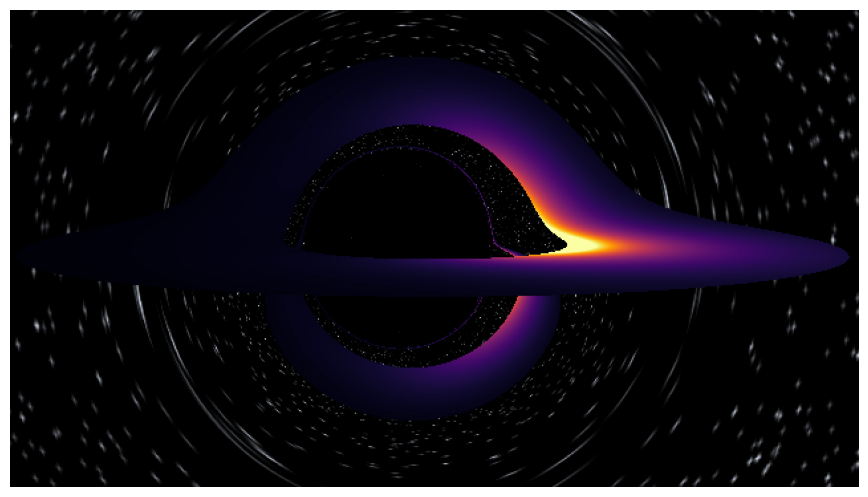

In [4]:
import math, importlib, time
import numpy as np
import matplotlib.pyplot as plt
import gpu_render as G
import flythrough_driver as FD
importlib.reload(G); importlib.reload(FD)

cfg = dict(FD.DEFAULTS)
cfg.update(res=(360, 640))                   # (height, width); try (720, 1280) once happy

sky = G.make_starfield(device=device)
lut = G.inferno_lut(device)
cam = FD.camera_at(0.12, cfg)                # a nice three-quarter angle
opts = dict(n_steps=cfg["n_steps"], C0=cfg["C0"], use_compile=cfg["use_compile"])
t0 = time.time()
frame, bright, otype = G.render_frame(cam, cfg["a"], sky, lut, 1.0, device,
                                      return_raw=True, **opts)
scale = torch.quantile(bright[otype == 2], 0.995).item()
t1 = time.time()
frame = G.render_frame(cam, cfg["a"], sky, lut, scale, device, **opts)
frame = frame.cpu().numpy()
print(f"first render {t1 - t0:.1f}s (includes compile), second {time.time() - t1:.1f}s, "
      f"{'compiled' if G._STEP['compiled'] else 'eager'} mode")
plt.figure(figsize=(11, 6.2)); plt.imshow(frame); plt.axis("off"); plt.show()

### Optional: check the compiled path against eager

Renders a small frame both ways. Expect a tiny difference (fused kernels reorder
floating-point arithmetic), with at most a handful of pixels differing visibly,
usually on near-critical rays at the photon ring.

In [5]:
small = FD.camera_at(0.12, dict(cfg, res=(144, 256)))
f_eager = G.render_frame(small, cfg["a"], sky, lut, scale, device, n_steps=cfg["n_steps"],
                         C0=cfg["C0"], use_compile=False)
f_comp = G.render_frame(small, cfg["a"], sky, lut, scale, device, n_steps=cfg["n_steps"],
                        C0=cfg["C0"], use_compile=True)
d = (f_eager - f_comp).abs().amax(-1)
print(f"mean |diff| {d.mean().item():.2e}, pixels off by more than one 8-bit level: "
      f"{int((d > 1 / 255).sum())} / {d.numel()}")

mean |diff| 3.78e-06, pixels off by more than one 8-bit level: 4 / 36864


## Render the flythrough

Full orbit, encoded to `flythrough.mp4` (and a lighter `flythrough.gif`) in
`/kaggle/working`, downloadable from the Output tab. The defaults (640x360,
96 frames) are a fast first pass; the progress lines show seconds per frame and
an ETA, so you can extrapolate before scaling up. Cost scales with pixels x
frames: 1280x720 is 4x the pixels of 640x360, 1920x1080 is 9x.

In [6]:
cfg = dict(FD.DEFAULTS)
cfg.update(res=(360, 640), n_frames=96, fps=30)   # e.g. res=(720, 1280), n_frames=144 for a glossier clip

frames = FD.render_flythrough(cfg, device,
                              out_mp4="/kaggle/working/flythrough.mp4",
                              out_gif="/kaggle/working/flythrough.gif")
print("done:", len(frames), "frames")

disk_scale = 1.884 (calibration frame 1.0s, compiled mode; the first frame of a session includes compiling)
frame 4/96  1.03s/frame  elapsed 0.1 min  eta 1.6 min
frame 8/96  1.06s/frame  elapsed 0.1 min  eta 1.5 min
frame 12/96  1.07s/frame  elapsed 0.2 min  eta 1.5 min
frame 16/96  1.06s/frame  elapsed 0.3 min  eta 1.4 min
frame 20/96  1.06s/frame  elapsed 0.4 min  eta 1.3 min
frame 24/96  1.07s/frame  elapsed 0.4 min  eta 1.3 min
frame 28/96  1.05s/frame  elapsed 0.5 min  eta 1.2 min
frame 32/96  1.04s/frame  elapsed 0.6 min  eta 1.1 min
frame 36/96  1.01s/frame  elapsed 0.6 min  eta 1.1 min
frame 40/96  0.96s/frame  elapsed 0.7 min  eta 1.0 min
frame 44/96  0.93s/frame  elapsed 0.8 min  eta 0.9 min
frame 48/96  0.86s/frame  elapsed 0.8 min  eta 0.8 min
frame 52/96  0.81s/frame  elapsed 0.9 min  eta 0.7 min
frame 56/96  0.81s/frame  elapsed 0.9 min  eta 0.7 min
frame 60/96  0.83s/frame  elapsed 1.0 min  eta 0.6 min
frame 64/96  0.84s/frame  elapsed 1.0 min  eta 0.5 min
frame 68/96  0

In [7]:
from IPython.display import Video
Video("/kaggle/working/flythrough.mp4", embed=True, width=900)


## Notes

- **Spin.** `a` runs 0 to just under 1 (M = 1 units). Higher spin flattens the
  shadow's near side more and tightens the inner disk.
- **Framing.** `incl0` near 90 is edge-on (disk as a line); lower tips the disk
  into view. `fov` and `dist0` set how close and wide the shot feels.
- **Quality vs time.** Cost scales with pixels x frames, and with how many
  steps rays stay in flight. Every ray is in flight for the first ~300 steps
  (they start at r = 55), and after that finished rays are dropped from the
  batch, so the tail of `n_steps` is cheap. Lowering `n_steps` below ~1500
  leaves outgoing sky rays unfinished (dark specks); if a run is slow, lower the
  resolution or frame count instead.
- **Speed.** Each integration step (RK4 with four Kerr right-hand sides, pole
  reflection, and the hit tests) is fused with `torch.compile`, turning hundreds
  of small eager kernels per step into a few. If compilation is not available it
  falls back to eager mode with a warning; set `use_compile=False` in the config
  to force eager.
- This render uses float32 for speed. The C++ engine in `simulation/` is the
  reference; this notebook matches its geodesics to a fraction of a degree.
